In [125]:
print("БЛОК 1.1: Настройки визуализации с подробными комментариями")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional,
        LayerNormalization, Input
)
from tensorflow.keras.regularizers import l2

# Глобальные настройки визуализации (будут применяться ко всем графикам)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13
})

MAX_LEN = 150
Number_Signs = 8
active_vocab = 5000  # Задано в Tokenizer(num_words=5000)

БЛОК 1.1: Настройки визуализации с подробными комментариями


In [126]:
print("БЛОК 2: Проверка доступности файла данных")
# Путь к датасету (raw-строка r"" экранирует обратные слеши Windows)
DATASET_PATH = r"C:\Users\User\Desktop\Recurrent_Neural_Network_Project_Predicting_Response_Status\source\rureviews-master\women-clothing-accessories.3-class.balanced.csv"

# Проверка существования файла до загрузки
file_exists = os.path.exists(DATASET_PATH)

# Форматированный вывод результата проверки
status_icon = " Доступен" if file_exists else " Отсутствует"
print(f"\n{'='*12} ПРОВЕРКА ДАТАСЕТА {'='*12}")
print(f" Путь   : {DATASET_PATH}")
print(f" Статус : {status_icon}")
print("=" * 46)

# Опционально: прерывание выполнения при отсутствии файла
if not file_exists:
   raise FileNotFoundError("Файл не найден. Проверьте путь или структуру директорий.")

БЛОК 2: Проверка доступности файла данных

============ ПРОВЕРКА ДАТАСЕТА ============
 Путь   : C:\Users\User\Desktop\Recurrent_Neural_Network_Project_Predicting_Response_Status\source\rureviews-master\women-clothing-accessories.3-class.balanced.csv
 Статус :  Доступен


In [127]:
print("БЛОК 3: Загрузка датасета в DataFrame")

# Загрузка данных из TSV-файла (разделитель табуляции \t)
# Для согласованности используем константу DATASET_PATH из Блока 2
df = pd.read_csv(DATASET_PATH, sep="\t")

# Структурированный вывод мета-информации
print("\n" + "="*48)
print(" ДАТАСЕТ УСПЕШНО ЗАГРУЖЕН")
print("="*48)
print(f" Размер:        {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f" Столбцы:      {', '.join(df.columns)}")
print(f" Память:       {df.memory_usage(deep=True).sum() / 1024**2:.2f} МБ")
print("="*48)

# Вывод первых 3 строк в компактном табличном виде
print("\n ПЕРВЫЕ 3 СТРОКИ:")
print(df.head(3).to_string(index=False, max_colwidth=50))

БЛОК 3: Загрузка датасета в DataFrame

 ДАТАСЕТ УСПЕШНО ЗАГРУЖЕН
 Размер:        90,000 строк × 2 столбцов
 Столбцы:      review, sentiment
 Память:       34.82 МБ

 ПЕРВЫЕ 3 СТРОКИ:
                                            review sentiment
качество плохое пошив ужасный (горловина напере...  negative
Товар отдали другому человеку, я не получила по...  negative
Ужасная синтетика! Тонкая, ничего общего с пред...  negative


БЛОК 4: Анализ распределения целевой переменной

 РАСПРЕДЕЛЕНИЕ КЛАССОВ 'sentiment'
Класс             Количество       Доля
--------------------------------------------------
negative              30,000     33.33%
neautral              30,000     33.33%
positive              30,000     33.33%
--------------------------------------------------
Всего                 90,000    100.00%


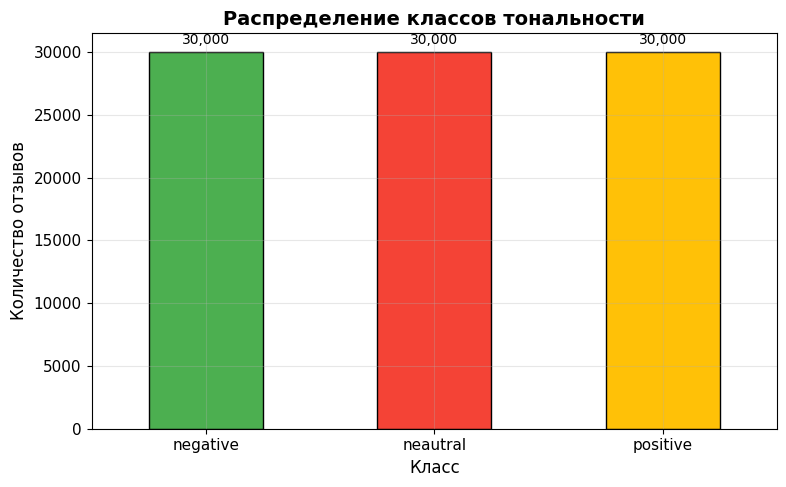


 Коэффициент дисбаланса (max/min): 1.00 →  Баланс приемлемый


In [128]:
print("БЛОК 4: Анализ распределения целевой переменной")

# Подсчёт количества примеров для каждого класса
counts = df['sentiment'].value_counts()

# Вывод распределения классов
print("\n" + "="*50)
print(" РАСПРЕДЕЛЕНИЕ КЛАССОВ 'sentiment'")
print("="*50)
print(f"{'Класс':<15} {'Количество':>12} {'Доля':>10}")
print("-"*50)
for label, count in counts.items():
    percent = count / len(df) * 100
    print(f"{str(label):<15} {count:>12,} {percent:>9.2f}%")
print("-"*50)
print(f"{'Всего':<15} {len(df):>12,} {'100.00%':>10}")
print("="*50)

# Визуализация: столбчатая диаграмма распределения
plt.figure(figsize=(8, 5))
bars = counts.plot(kind='bar', color=['#4CAF50', '#F44336', '#FFC107'], edgecolor='black')

# Добавление подписей значений на столбцы
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + len(df)*0.005,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.title('Распределение классов тональности', fontsize=14, fontweight='bold')
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество отзывов', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Проверка на дисбаланс (порог: отношение макс/мин > 2)
ratio = counts.max() / counts.min()
imbalance_warning = " Дисбаланс!" if ratio > 2 else " Баланс приемлемый"
print(f"\n Коэффициент дисбаланса (max/min): {ratio:.2f} → {imbalance_warning}")
if ratio > 2:
    print(" Рекомендация: использовать class_weight='balanced' при обучении модели")

In [129]:
print("БЛОК 5: Просмотр исходных данных (первые 30 строк)")

# Структурированный вывод первых 30 строк датасета
print("\n" + "="*80)
print(" ИСХОДНЫЕ ДАННЫЕ: ПЕРВЫЕ 30 ЗАПИСЕЙ")
print("="*80)

# Вывод с ограничениями для читаемости:
# - index=False: скрыть индекс (экономит место)
# - max_colwidth=60: обрезать длинные тексты отзывов
# - max_rows=30: показать ровно 30 строк как запрошено
print(df.head(30).to_string(
    index=False,
    max_colwidth=60,
    max_rows=30
))

print("="*80)

# Краткая сводка по типам данных и пропускам в просмотренном фрагменте
print("\n СВОДКА ПО ФРАГМЕНТУ (30 строк):")
print(f"• Пропуски в 'review':  {df['review'].head(30).isna().sum()}")
print(f"• Пропуски в 'sentiment': {df['sentiment'].head(30).isna().sum()}")
print(f"• Уникальных классов:   {df['sentiment'].head(30).nunique()}")
print(f"• Типы данных:\n{df.dtypes.to_string()}")

БЛОК 5: Просмотр исходных данных (первые 30 строк)

 ИСХОДНЫЕ ДАННЫЕ: ПЕРВЫЕ 30 ЗАПИСЕЙ
                                                      review sentiment
качество плохое пошив ужасный (горловина наперекос) Фото ...  negative
Товар отдали другому человеку, я не получила посылку. Лад...  negative
Ужасная синтетика! Тонкая, ничего общего с представленной...  negative
товар не пришел, продавец продлил защиту без моего соглас...  negative
               Кофточка голая синтетика, носить не возможно.  negative
                                       Очень глубокие проймы  negative
Я недовольна заказом.Я вот одного не понимаю почему внизу...  negative
заказала размер s на от 64,об 94,начнем с того, что влезт...  negative
Заказ я сделала в июле. С тех пор посылка отслеживалась д...  negative
                                    Ужасное качество товара!  negative
      короткая кофта нитки торчат,не суразно выглядит вообще  negative
                  ткань приятная. вот только пятно на спине.

In [130]:
print("БЛОК 6: Фильтрация и просмотр положительных отзывов")

# Фильтрация: оставляем только строки с меткой 'positive'
df_positive = df[df['sentiment'] == 'positive']

# Форматированный вывод статистики и примеров
print("\n" + "="*65)
print(" АНАЛИЗ КЛАССА: POSITIVE")
print("="*65)
print(f" Найдено отзывов: {len(df_positive):,} ({len(df_positive)/len(df)*100:.2f}%)")
print("="*65)

# Вывод первых 15 примеров для визуальной проверки качества текста
print("\n ПРИМЕРЫ (первые 15):")
print(df_positive.head(15).to_string(index=False, max_colwidth=75))
print("="*65)

# Быстрая проверка на аномалии в подвыборке
if df_positive.empty:
    print(" ВНИМАНИЕ: положительных отзывов не найдено. Проверьте регистр или орфографию меток.")
else:
    print(f" Мин. длина текста: {df_positive['review'].str.len().min()} симв.")
    print(f" Макс. длина текста: {df_positive['review'].str.len().max()} симв.")

БЛОК 6: Фильтрация и просмотр положительных отзывов

 АНАЛИЗ КЛАССА: POSITIVE
 Найдено отзывов: 30,000 (33.33%)

 ПРИМЕРЫ (первые 15):
                                                                     review sentiment
                                       Все совпадает! К покупке рекомендую!  positive
                                                  по размеру) качественные)  positive
Прекрасная, качественая рубашка! Искала простую прямую оверсайз рубашку....  positive
Пришло через 2 месяца. Очень долго, но пуловер хороший, мягкий, как в оп...  positive
Заказ дошел быстро. Соответствует описанию. Кривые строчки, тянет швы. М...  positive
                        Приятная к телу,  L  на 42 свободно, так как хотела  positive
платье хорошего качества, нитки нигде не торчат. на 46 размер брала М. п...  positive
просто огонь!!! очень крутая шапка, толстая и прекрасный помпон. размер,...  positive
платье оставило двоякое впечатление,само оно симпатичное и приятное на о...  positive
Кофта

In [131]:
print("БЛОК 7: Подсчёт непустых значений по столбцам")

# Подсчёт количества непустых (non-NA) значений в каждом столбце
non_null_counts = df.count()

# Форматированный вывод статистики пропусков
print("\n" + "="*55)
print(" ПОЛНОТА ДАННЫХ: НЕПУСТЫЕ ЗНАЧЕНИЯ")
print("="*55)
print(f"{'Столбец':<25} {'Заполнено':>12} {'Пропуски':>10}")
print("-"*55)

total_rows = len(df)
for col, count in non_null_counts.items():
    missing = total_rows - count
    missing_pct = missing / total_rows * 100
    print(f"{col:<25} {count:>12,} {missing:>9,} ({missing_pct:5.2f}%)")

print("-"*55)
print(f"{'Всего строк':<25} {total_rows:>12,}")
print("="*55)

# Быстрая диагностика: есть ли столбцы с пропусками >5%
cols_with_missing = [col for col in df.columns if df[col].isna().mean() > 0.05]
if cols_with_missing:
    print(f"\n Столбцы с пропусками >5%: {', '.join(cols_with_missing)}")
    print(" Рекомендация: рассмотреть импутацию или удаление перед обучением")
else:
    print("\n Все столбцы заполнены более чем на 95% — данные готовы к предобработке")

БЛОК 7: Подсчёт непустых значений по столбцам

 ПОЛНОТА ДАННЫХ: НЕПУСТЫЕ ЗНАЧЕНИЯ
Столбец                      Заполнено   Пропуски
-------------------------------------------------------
review                          90,000         0 ( 0.00%)
sentiment                       90,000         0 ( 0.00%)
-------------------------------------------------------
Всего строк                     90,000

 Все столбцы заполнены более чем на 95% — данные готовы к предобработке


In [132]:
print("БЛОК 8: Фильтрация и просмотр нейтральных/остальных отзывов")

# Фильтрация: исключаем 'positive' и 'negative'
# В 3-классовом датасете здесь останутся 'neutral' и возможные опечатки (напр., 'neautral')
df_neutral_others = df[(df['sentiment'] != 'positive') & (df['sentiment'] != 'negative')]

# Форматированный вывод статистики и уникальных меток
print("\n" + "="*65)
print(" АНАЛИЗ ОСТАВШИХСЯ КЛАССОВ (NEUTRAL / ДРУГИЕ)")
print("="*65)
print(f" Найдено отзывов: {len(df_neutral_others):,} ({len(df_neutral_others)/len(df)*100:.2f}%)")
print(f" Уникальные метки  : {df_neutral_others['sentiment'].unique()}")
print("="*65)

# Вывод первых 15 примеров для визуальной проверки стиля текста
print("\n ПРИМЕРЫ (первые 15):")
if not df_neutral_others.empty:
    print(df_neutral_others.head(15).to_string(index=False, max_colwidth=75))
else:
    print(" Выборка пуста. Проверьте регистр или орфографию меток в исходном файле.")
print("="*65)

БЛОК 8: Фильтрация и просмотр нейтральных/остальных отзывов

 АНАЛИЗ ОСТАВШИХСЯ КЛАССОВ (NEUTRAL / ДРУГИЕ)
 Найдено отзывов: 30,000 (33.33%)
 Уникальные метки  : ['neautral']

 ПРИМЕРЫ (первые 15):
                                                                     review sentiment
Пришли с пятном. До МО дошёл товаров за 12 дней, трек отслеживался, запа...  neautral
посылка шла больше двух месяцев, 72 дня, нам успели черно белый дресс ко...  neautral
Заказ пришел вовремя. Качество, конечно, так себе. Собственно говоря за ...  neautral
                                                        думала будет толще.  neautral
Ткань синтетика голая, прям  не приятная на ощупь, проймы для рукава мал...  neautral
Пришёл костюм менее чем за месяц, качество расстроило, открывала спор. К...  neautral
               пришли довольно быстро, оказались малы да и ткань как 2 кожа  neautral
Пижама пришла с браком, разводы от краски, темные пятна. В общем плохая ...  neautral
                            

In [133]:
print("БЛОК 9: Анализ длины отзывов (количество слов)")

# Добавление столбца с количеством слов в каждом отзыве
# str(x) — защита от NaN, split() — токенизация по пробелам (базовая)
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

# Форматированный вывод: первые 10 примеров с длиной
print("\n" + "="*70)
print(" ПРИМЕРЫ ОТЗЫВОВ С ДЛИНОЙ (первые 10)")
print("="*70)
print(df[['review', 'review_length']].head(10).to_string(
    index=False,
    max_colwidth=60
))
print("="*70)

# Сводная статистика по длине отзывов
print("\n СТАТИСТИКА ДЛИНЫ ОТЗЫВОВ (в словах):")
stats = df['review_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
print(f"{'Метрика':<20} {'Значение':>10}")
print("-"*30)
print(f"{'Среднее (mean)':<20} {stats['mean']:>10.2f}")
print(f"{'Стд. откл. (std)':<20} {stats['std']:>10.2f}")
print(f"{'Минимум':<20} {stats['min']:>10.0f}")
print(f"{'25-й перцентиль':<20} {stats['25%']:>10.0f}")
print(f"{'Медиана (50%)':<20} {stats['50%']:>10.0f}")
print(f"{'75-й перцентиль':<20} {stats['75%']:>10.0f}")
print(f"{'90-й перцентиль':<20} {stats['90%']:>10.0f}")
print(f"{'95-й перцентиль':<20} {stats['95%']:>10.0f}")
print(f"{'Максимум':<20} {stats['max']:>10.0f}")
print("-"*30)

# Рекомендация по выбору maxlen для pad_sequences
q90 = int(stats['90%'])
print(f"\n Рекомендация для pad_sequences: maxlen={q90} охватит ~90% отзывов")

БЛОК 9: Анализ длины отзывов (количество слов)

 ПРИМЕРЫ ОТЗЫВОВ С ДЛИНОЙ (первые 10)
                                                      review  review_length
качество плохое пошив ужасный (горловина наперекос) Фото ...             24
Товар отдали другому человеку, я не получила посылку. Лад...             12
Ужасная синтетика! Тонкая, ничего общего с представленной...             30
товар не пришел, продавец продлил защиту без моего соглас...             13
               Кофточка голая синтетика, носить не возможно.              6
                                       Очень глубокие проймы              3
Я недовольна заказом.Я вот одного не понимаю почему внизу...             22
заказала размер s на от 64,об 94,начнем с того, что влезт...             51
Заказ я сделала в июле. С тех пор посылка отслеживалась д...            118
                                    Ужасное качество товара!              3

 СТАТИСТИКА ДЛИНЫ ОТЗЫВОВ (в словах):
Метрика                Значение
-------

In [134]:
print("БЛОК 10: Базовая статистика длины отзывов")

# Форматированный вывод ключевых метрик длины
print("\n" + "="*50)
print(" СТАТИСТИКА ДЛИНЫ ОТЗЫВОВ (в словах)")
print("="*50)
print(f"{'Минимальная длина:':<30} {df['review_length'].min():>8,} слов")
print(f"{'Максимальная длина:':<30} {df['review_length'].max():>8,} слов")
print(f"{'Средняя длина (mean):':<30} {df['review_length'].mean():>8.2f} слов")
print(f"{'Медиана (50%):':<30} {df['review_length'].median():>8.0f} слов")
print(f"{'Стандартное отклонение:':<30} {df['review_length'].std():>8.2f} слов")
print("="*50)

# Интерпретация для выбора гиперпараметров
mean_len = df['review_length'].mean()
median_len = df['review_length'].median()
max_len = df['review_length'].max()

print(f"\n Выводы для предобработки:")
print(f"Разброс данных: [{df['review_length'].min()}, {max_len}] слов")
print(f"{' Медиана ≈ среднее' if abs(mean_len - median_len) / mean_len < 0.2 else ' Распределение скошено'} (разница: {abs(mean_len - median_len):.1f} слов)")
print(f"Рекомендуемый maxlen: {int(median_len * 1.5)}–{int(df['review_length'].quantile(0.9))} (баланс между охватом и разреженностью)")

БЛОК 10: Базовая статистика длины отзывов

 СТАТИСТИКА ДЛИНЫ ОТЗЫВОВ (в словах)
Минимальная длина:                    0 слов
Максимальная длина:                 193 слов
Средняя длина (mean):             20.01 слов
Медиана (50%):                       14 слов
Стандартное отклонение:           19.89 слов

 Выводы для предобработки:
Разброс данных: [0, 193] слов
 Распределение скошено (разница: 6.0 слов)
Рекомендуемый maxlen: 21–43 (баланс между охватом и разреженностью)


БЛОК 11: Анализ перцентилей длины отзывов

 ПЕРЦЕНТИЛИ ДЛИНЫ ОТЗЫВОВ (в словах)
Перцентиль                  Значение Интерпретация            
------------------------------------------------------------
Медиана (50%)                     14 Половина отзывов короче  
75-й перцентиль                   25 75% отзывов короче этого 
90-й перцентиль                   43  Рекомендуется maxlen    
95-й перцентиль                   58 Макс. охват (95% данных) 

 РЕКОМЕНДАЦИИ ДЛЯ ПАДДИНГА:
   • maxlen=43 → охватит ~90% отзывов, меньше разреженных нулей
   • maxlen=58 → охватит ~95% отзывов, но больше вычислительных затрат
   • Компромисс: начать с maxlen=43, при недообучении → увеличить


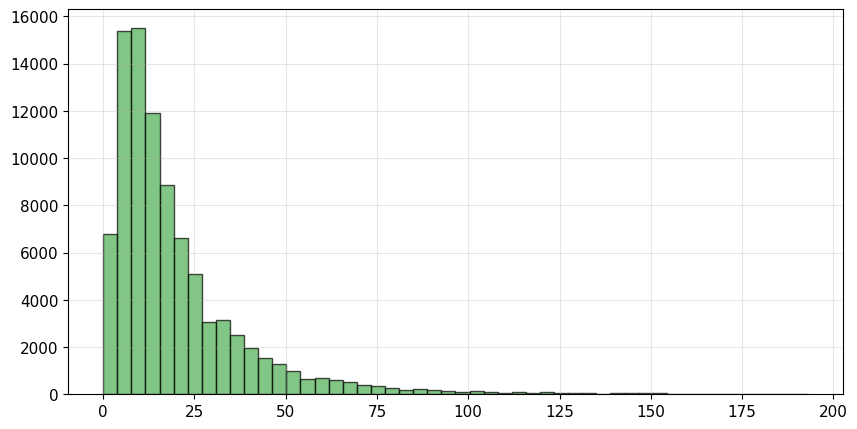

In [135]:
print("БЛОК 11: Анализ перцентилей длины отзывов")

# Форматированный вывод перцентилей с интерпретацией
print("\n" + "="*60)
print(" ПЕРЦЕНТИЛИ ДЛИНЫ ОТЗЫВОВ (в словах)")
print("="*60)
print(f"{'Перцентиль':<25} {'Значение':>10} {'Интерпретация':<25}")
print("-"*60)

# Расчёт и вывод ключевых перцентилей
percentiles = [0.5, 0.75, 0.9, 0.95]
labels = {
    0.5: "Медиана (50%)",
    0.75: "75-й перцентиль",
    0.9: "90-й перцентиль",
    0.95: "95-й перцентиль"
}

for p in percentiles:
    value = int(df['review_length'].quantile(p))
    interpretation = {
        0.5: "Половина отзывов короче",
        0.75: "75% отзывов короче этого",
        0.9: " Рекомендуется maxlen",
        0.95: "Макс. охват (95% данных)"
    }[p]
    print(f"{labels[p]:<25} {value:>10,} {interpretation:<25}")

print("="*60)

# Рекомендации для pad_sequences на основе перцентилей
q90 = int(df['review_length'].quantile(0.9))
q95 = int(df['review_length'].quantile(0.95))

print(f"\n РЕКОМЕНДАЦИИ ДЛЯ ПАДДИНГА:")
print(f"   • maxlen={q90} → охватит ~90% отзывов, меньше разреженных нулей")
print(f"   • maxlen={q95} → охватит ~95% отзывов, но больше вычислительных затрат")
print(f"   • Компромисс: начать с maxlen={q90}, при недообучении → увеличить")

# Визуализация: гистограмма с маркерами перцентилей
plt.figure(figsize=(10, 5))
df['review_length'].hist(bins=50, edgecolor='black', alpha=0.7, color='#4CAF50')

# Вертикальные линии для перцентилей
colors = {0.5: 'blue', 0.75: 'orange', 0.9: 'red', 0.95: 'purple'}
for p, color in colors.items():
    val = df['review_length'].quantile(p)
    plt.axvline

In [136]:
print("БЛОК 12: Токенизация и преобразование текста в последовательности индексов")

# Инициализация токенизатора:
# num_words=3000 → сохраняет только 3000 самых частотных токенов (индексы 1..3000)
# oov_token="<OOV>" → маркер для слов, вышедших за пределы словаря
tokenizer = Tokenizer(num_words=3000, oov_token="<OOV>")

# Построение словаря: подсчёт частот, сортировка, присвоение индексов
tokenizer.fit_on_texts(df['review'])

# Преобразование текстов в последовательности целых чисел (индексов слов)
sequences = tokenizer.texts_to_sequences(df['review'])

# Структурированный вывод результатов токенизации
print("\n" + "="*70)
print(" РЕЗУЛЬТАТЫ ТОКЕНИЗАЦИИ")
print("="*70)
print(f" Уникальных слов в корпусе:       {len(tokenizer.word_index):,}")
print(f" Размер активного словаря:        3000 (num_words)")
print(f" Индекс OOV-токена:               {tokenizer.word_index.get('<OOV>', 'N/A')}")
print(f" Сгенерировано последовательностей: {len(sequences):,}")
print("="*70)

# Примеры преобразования: текст → индексы
print("\n ПРИМЕРЫ (первые 5 отзывов):")
for i in range(min(5, len(df))):
    text_preview = str(df['review'].iloc[i])[:80] + "..."
    seq_preview = sequences[i][:12]
    print(f" Текст  : {text_preview}")
    print(f" Индексы: {seq_preview}... (длина: {len(sequences[i])})")
    print("-" * 60)

БЛОК 12: Токенизация и преобразование текста в последовательности индексов

 РЕЗУЛЬТАТЫ ТОКЕНИЗАЦИИ
 Уникальных слов в корпусе:       55,993
 Размер активного словаря:        3000 (num_words)
 Индекс OOV-токена:               1
 Сгенерировано последовательностей: 90,000

 ПРИМЕРЫ (первые 5 отзывов):
 Текст  : качество плохое пошив ужасный (горловина наперекос) Фото не соответствует Ткань ...
 Индексы: [13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435, 350]... (длина: 24)
------------------------------------------------------------
 Текст  : Товар отдали другому человеку, я не получила посылку. Ладно хоть деньги вернули....
 Индексы: [12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15, 31]... (длина: 12)
------------------------------------------------------------
 Текст  : Ужасная синтетика! Тонкая, ничего общего с представленной картинкой, не яркая, р...
 Индексы: [435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562, 350, 1]... (длина: 30)
-----------------------------------------------------------

In [137]:
print("БЛОК 13: Вывод словаря токенизатора (word_index)")

# Словарь: слово → целочисленный индекс
word_index = tokenizer.word_index

# ️ Структурированный вывод: статистика + читаемое превью
print("\n" + "="*60)
print(" СЛОВАРЬ ТОКЕНИЗАТОРА (word_index)")
print("="*60)
print(f" Всего уникальных слов в корпусе: {len(word_index):,}")
print(f" Активный словарь (num_words):    3000")
print(f" Диапазон индексов:               1 (OOV) → {min(3000, len(word_index))}")
print("-" * 60)

# Выводим только топ-15 самых частотных слов (индексы растут с убыванием частоты)
print(" Топ-15 наиболее частотных слов:")
for i, (word, idx) in enumerate(sorted(word_index.items(), key=lambda x: x[1])[:15]):
    print(f"   {i+1:2d}. '{word:<15}' → индекс: {idx}")
print("=" * 60)
print(" Полный словарь ({:,} записей) не выводится для экономии памяти.".format(len(word_index)))
print("   Обращение: word_index['пример_слова'] → вернёт индекс или KeyError")

БЛОК 13: Вывод словаря токенизатора (word_index)

 СЛОВАРЬ ТОКЕНИЗАТОРА (word_index)
 Всего уникальных слов в корпусе: 55,993
 Активный словарь (num_words):    3000
 Диапазон индексов:               1 (OOV) → 3000
------------------------------------------------------------
 Топ-15 наиболее частотных слов:
    1. '<OOV>          ' → индекс: 1
    2. 'не             ' → индекс: 2
    3. 'на             ' → индекс: 3
    4. 'и              ' → индекс: 4
    5. 'в              ' → индекс: 5
    6. 'очень          ' → индекс: 6
    7. 'но             ' → индекс: 7
    8. 'размер         ' → индекс: 8
    9. 'что            ' → индекс: 9
   10. 'как            ' → индекс: 10
   11. 'с              ' → индекс: 11
   12. 'товар          ' → индекс: 12
   13. 'качество       ' → индекс: 13
   14. 'продавец       ' → индекс: 14
   15. 'деньги         ' → индекс: 15
 Полный словарь (55,993 записей) не выводится для экономии памяти.
   Обращение: word_index['пример_слова'] → вернёт индекс или Key

In [138]:
print("БЛОК 14: Анализ уникальных меток целевой переменной")

# Получение уникальных значений столбца 'sentiment'
unique_labels = df['sentiment'].unique()

# Структурированный вывод с интерпретацией
print("\n" + "="*60)
print(" УНИКАЛЬНЫЕ КЛАССЫ В ДАТАСЕТЕ")
print("="*60)
print(f" Количество классов: {len(unique_labels)}")
print(f" Значения: {unique_labels}")
print("-" * 60)

БЛОК 14: Анализ уникальных меток целевой переменной

 УНИКАЛЬНЫЕ КЛАССЫ В ДАТАСЕТЕ
 Количество классов: 3
 Значения: ['negative' 'neautral' 'positive']
------------------------------------------------------------


In [139]:
print("БЛОК 15: Кодирование текстовых меток в числа")

# Словарь соответствия: строка → целое число
# 4 ключа вместо 3 — это очистка данных (опечатка 'neautral' часто встречается в ручных разметках)
label_map = {
    "positive": 0,
    "negative": 1,
    "neutral": 2,
    "neautral": 2  # ← исправление опечатки, чтобы не терять строки
}

# Преобразование столбца и приведение к числовому типу
df['sentiment'] = df['sentiment'].map(label_map).astype('int32')

# Контрольный вывод
print("\n" + "="*50)
print(" МЕТКИ УСПЕШНО ЗАКОДИРОВАНЫ")
print("="*50)
print(f" Уникальные значения: {sorted(df['sentiment'].dropna().unique())}")
print(f" Тип данных: {df['sentiment'].dtype}")
print(f" Пропуски после маппинга: {df['sentiment'].isna().sum()}")

if df['sentiment'].isna().sum() > 0:
    print(" ВНИМАНИЕ: Нераспознанные метки стали NaN → удалите или добавьте их в словарь")
else:
    print(" Все метки корректно преобразованы в числа")
print("="*50)

БЛОК 15: Кодирование текстовых меток в числа

 МЕТКИ УСПЕШНО ЗАКОДИРОВАНЫ
 Уникальные значения: [np.int32(0), np.int32(1), np.int32(2)]
 Тип данных: int32
 Пропуски после маппинга: 0
 Все метки корректно преобразованы в числа


In [140]:
print("БЛОК 16: Предварительный просмотр обработанного DataFrame")

# Визуальная проверка: как изменился датафрейм после маппинга меток
print("\n" + "="*80)
print(" ТЕКУЩЕЕ СОСТОЯНИЕ ДАТАСЕТА (первые 5 строк)")
print("="*80)
print(df.head().to_string(index=True, max_colwidth=60))
print("="*80)

# Автоматическая сводка структуры
print("\n СТРУКТУРА ТАБЛИЦЫ:")
print(f"• Размер          : {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f"• Столбцы         : {list(df.columns)}")
print(f"• Типы данных     :\n{df.dtypes.to_string()}")
print(f"• Пропуски в метках: {df['sentiment'].isna().sum()}")
print("="*80)

# Диагностика: если после map() появились NaN, значит в исходных данных были нераспознанные метки
if df['sentiment'].isna().sum() > 0:
    print("\n️ ВНИМАНИЕ: Обнаружены NaN в столбце 'sentiment'.")
    print(" Причина: В исходных данных встретились метки, которых нет в label_map.")
    print(" Решение: Добавьте их в словарь или удалите строки: df = df.dropna(subset=['sentiment'])")
else:
    print("\n Все преобразования применены успешно. Данные готовы к токенизации и паддингу.")

БЛОК 16: Предварительный просмотр обработанного DataFrame

 ТЕКУЩЕЕ СОСТОЯНИЕ ДАТАСЕТА (первые 5 строк)
                                                        review  sentiment  review_length
0  качество плохое пошив ужасный (горловина наперекос) Фото...          1             24
1  Товар отдали другому человеку, я не получила посылку. Ла...          1             12
2  Ужасная синтетика! Тонкая, ничего общего с представленно...          1             30
3  товар не пришел, продавец продлил защиту без моего согла...          1             13
4                Кофточка голая синтетика, носить не возможно.          1              6

 СТРУКТУРА ТАБЛИЦЫ:
• Размер          : 90,000 строк × 3 столбцов
• Столбцы         : ['review', 'sentiment', 'review_length']
• Типы данных     :
review           object
sentiment         int32
review_length     int64
• Пропуски в метках: 0

 Все преобразования применены успешно. Данные готовы к токенизации и паддингу.


In [141]:
print("БЛОК 17: Сохранение последовательностей индексов в DataFrame")

# Преобразование текстов в индексы и запись результата прямо в таблицу
# (хранение в столбце удобнее для фильтрации, валидации и train/test split)
df['sequences'] = tokenizer.texts_to_sequences(df['review'])

# Форматированный контроль результата
print("\n" + "="*70)
print(" СТОЛБЕЦ 'sequences' ДОБАВЛЕН В DataFrame")
print("="*70)
print(f" Обработано строк: {len(df['sequences']):,}")
print(f" Примеры длин последовательностей: {[len(s) for s in df['sequences'][:3]]}")
print(f" Индексы первых 3 отзывов (по 10 элементов):")
for i in range(min(3, len(df))):
    seq_preview = df['sequences'].iloc[i][:10]
    print(f"   [{i}] {seq_preview}... (всего: {len(df['sequences'].iloc[i])} слов)")
print("="*70)

# Быстрая проверка OOV-токенов
oov_count = sum(1 for seq in df['sequences'] for idx in seq if idx == 1)
oov_pct = oov_count / sum(len(s) for s in df['sequences']) * 100
print(f"\n Доля OOV-токенов (индекс 1): {oov_pct:.2f}%")
if oov_pct > 20:
    print(" Высокая доля неизвестных слов. Рассмотрите увеличение num_words или использование эмбеддингов")

БЛОК 17: Сохранение последовательностей индексов в DataFrame

 СТОЛБЕЦ 'sequences' ДОБАВЛЕН В DataFrame
 Обработано строк: 90,000
 Примеры длин последовательностей: [24, 12, 30]
 Индексы первых 3 отзывов (по 10 элементов):
   [0] [13, 259, 365, 316, 822, 1, 35, 2, 34, 26]... (всего: 24 слов)
   [1] [12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344]... (всего: 12 слов)
   [2] [435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562]... (всего: 30 слов)

 Доля OOV-токенов (индекс 1): 11.28%


In [142]:
print("БЛОК 18: Визуальная сверка: исходный текст - последовательность индексов")

# Структурированный вывод: текст и соответствующие индексы рядом
print("\n" + "="*85)
print(" СВЕРКА ПРЕОБРАЗОВАНИЯ: ТЕКСТ → ИНДЕКСЫ (первые 5 примеров)")
print("="*85)

# Форматируем вывод для наглядного сравнения
preview = df[['review', 'sequences']].head()
for idx, row in preview.iterrows():
    text_short = str(row['review'])[:70] + "..." if len(str(row['review'])) > 70 else row['review']
    seq_short = row['sequences'][:12]
    print(f" [{idx}] Текст  : {text_short}")
    print(f"   Индексы: {seq_short}... (длина: {len(row['sequences'])})")
    print("-" * 85)

print("="*85)
print(" Примечание: Индекс 1 = <OOV> (слово вне словаря), индекс 0 = padding")

БЛОК 18: Визуальная сверка: исходный текст → последовательность индексов

 СВЕРКА ПРЕОБРАЗОВАНИЯ: ТЕКСТ → ИНДЕКСЫ (первые 5 примеров)
 [0] Текст  : качество плохое пошив ужасный (горловина наперекос) Фото не соответств...
   Индексы: [13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435, 350]... (длина: 24)
-------------------------------------------------------------------------------------
 [1] Текст  : Товар отдали другому человеку, я не получила посылку. Ладно хоть деньг...
   Индексы: [12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15, 31]... (длина: 12)
-------------------------------------------------------------------------------------
 [2] Текст  : Ужасная синтетика! Тонкая, ничего общего с представленной картинкой, н...
   Индексы: [435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562, 350, 1]... (длина: 30)
-------------------------------------------------------------------------------------
 [3] Текст  : товар не пришел, продавец продлил защиту без моего согласия. от продав...
   Индексы: [1

In [143]:
print("БЛОК 19: Финальная проверка структуры перед предобработкой")

# Визуальный чекпоинт: убеждаемся, что все предыдущие шаги применены корректно
print("\n" + "="*85)
print(" ТЕКУЩЕЕ СОСТОЯНИЕ ДАТАСЕТА (первые 5 строк)")
print("="*85)
print(df.head().to_string(index=True, max_colwidth=50))
print("="*85)

# Автоматическая сводка для быстрой диагностики
print(f"\n Размер таблицы   : {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f" Имена столбцов   : {list(df.columns)}")
print(f" Типы данных      :\n{df.dtypes.to_string()}")
print(f" Пропуски (NaN)   :\n{df.isna().sum().to_string()}")
print("="*85)

# Чек-лист готовности к следующему этапу
checks = {
    "Столбец 'sequences' существует": 'sequences' in df.columns,
    "Метки преобразованы в int": df['sentiment'].dtype in ['int32', 'int64', 'Int32'],
    "Нет критических пропусков в метках": df['sentiment'].notna().all(),
    "Последовательности не пустые": all(len(s) > 0 for s in df['sequences'].head(100))
}
print("\n СТАТУС ГОТОВНОСТИ:")
for check, status in checks.items():
    print(f"   {'-' if status else '+'} {check}")

БЛОК 19: Финальная проверка структуры перед предобработкой

 ТЕКУЩЕЕ СОСТОЯНИЕ ДАТАСЕТА (первые 5 строк)
                                              review  sentiment  review_length                                          sequences
0  качество плохое пошив ужасный (горловина напер...          1             24  [13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435...
1  Товар отдали другому человеку, я не получила п...          1             12  [12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15...
2  Ужасная синтетика! Тонкая, ничего общего с пре...          1             30  [435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562...
3  товар не пришел, продавец продлил защиту без м...          1             13  [12, 2, 42, 14, 1152, 543, 112, 899, 1, 85, 45...
4      Кофточка голая синтетика, носить не возможно.          1              6                        [322, 1490, 58, 75, 2, 467]

 Размер таблицы   : 90,000 строк × 4 столбцов
 Имена столбцов   : ['review', 'sentiment', 'review_length', 'sequen

In [144]:
print("БЛОК 20: Очистка DataFrame от служебных столбцов")

# Удаляем исходный текст и вспомогательный столбец длины
# axis=1 - удаление по столбцам. Текст уже преобразован в 'sequences',
# а 'review_length' использовался только для EDA и выбора maxlen
df = df.drop(["review", "review_length"], axis=1)

# Визуальная проверка результата
print("\n" + "="*65)
print(" СЛУЖЕБНЫЕ СТОЛБЦЫ УДАЛЕНЫ")
print("="*65)
print(df.head().to_string(index=False, max_colwidth=60))
print("="*65)

# Итоговая структура перед формированием тензоров X/y
print(f"\n Размер таблицы : {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f" Оставшиеся столбцы: {list(df.columns)}")
print(f" Типы данных:\n{df.dtypes.to_string()}")

# Контроль целостности данных
expected_cols = {'sequences', 'sentiment'}
if set(df.columns) == expected_cols:
    print("\n Структура корректна: готовы к разделению на X и y")
else:
    print(f"\n Ожидались столбцы {expected_cols}, получены {set(df.columns)}")

БЛОК 20: Очистка DataFrame от служебных столбцов

 СЛУЖЕБНЫЕ СТОЛБЦЫ УДАЛЕНЫ
 sentiment                                                    sequences
         1 [13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435, 350, 1, 2...
         1          [12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15, 31]
         1 [435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562, 350, 1, 4...
         1     [12, 2, 42, 14, 1152, 543, 112, 899, 1, 85, 45, 1149, 1]
         1                                  [322, 1490, 58, 75, 2, 467]

 Размер таблицы : 90,000 строк × 2 столбцов
 Оставшиеся столбцы: ['sentiment', 'sequences']
 Типы данных:
sentiment     int32
sequences    object

 Структура корректна: готовы к разделению на X и y


БЛОК 21: Визуализация распределения классов после предобработки


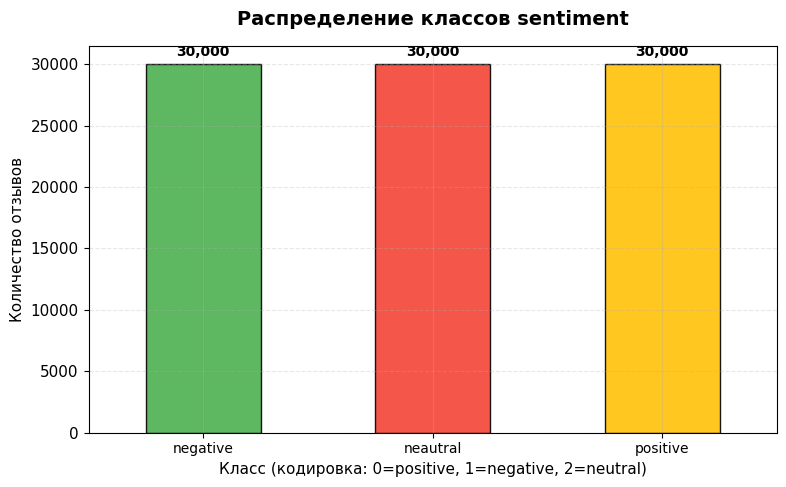


 СТАТИСТИКА РАСПРЕДЕЛЕНИЯ (после очистки)
   Класс 0 (positive): 30,000 примеров (33.33%)
   Класс 1 (negative): 30,000 примеров (33.33%)
   Класс 2 (neutral ): 30,000 примеров (33.33%)

 Коэффициент дисбаланса (max/min): 1.00
 Распределение сбалансировано — можно обучать без корректировок


In [145]:
print("БЛОК 21: Визуализация распределения классов после предобработки")

# Построение столбчатой диаграммы распределения меток
plt.figure(figsize=(8, 5))  # Компактный размер для отчёта/презентации
bars = counts.plot(
    kind='bar',
    color=['#4CAF50', '#F44336', '#FFC107'],  # green/red/yellow для поз/нег/нейтр
    edgecolor='black',                          # Контур для чёткости при печати
    alpha=0.9                                   # Лёгкая прозрачность
)

# Добавление числовых подписей на столбцы
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Центрирование по X
        height + len(df) * 0.005,            # Небольшой отступ сверху
        f'{int(height):,}',                  # Формат с разделителем тысяч
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Оформление графика
plt.title('Распределение классов sentiment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Класс (кодировка: 0=positive, 1=negative, 2=neutral)', fontsize=11)
plt.ylabel('Количество отзывов', fontsize=11)
plt.xticks(rotation=0, fontsize=10)  # Горизонтальные подписи для читаемости
plt.grid(axis='y', alpha=0.3, linestyle='--')  # Сетка только по Y
plt.tight_layout()  # Автоматическая подгонка, чтобы не обрезались подписи
plt.show()

# Текстовая сводка для отчёта
print("\n" + "="*60)
print(" СТАТИСТИКА РАСПРЕДЕЛЕНИЯ (после очистки)")
print("="*60)
for cls in sorted(df['sentiment'].dropna().unique()):
    count = (df['sentiment'] == cls).sum()
    pct = count / len(df) * 100
    label = {0: 'positive', 1: 'negative', 2: 'neutral'}.get(cls, f'class_{cls}')
    print(f"   Класс {cls} ({label:<8}): {count:>6,} примеров ({pct:5.2f}%)")
print("="*60)

# Автоматическая оценка баланса
if len(counts) >= 2:
    ratio = counts.max() / counts.min()
    print(f"\n Коэффициент дисбаланса (max/min): {ratio:.2f}")
    if ratio > 3:
        print("️ Сильный дисбаланс → используйте class_weight='balanced' или oversampling")
    elif ratio > 1.5:
        print(" Умеренный дисбаланс → мониторьте метрики по классам (F1, recall)")
    else:
        print(" Распределение сбалансировано — можно обучать без корректировок")

In [146]:
print("БЛОК 22: Анализ размера словаря и обоснование ограничения")

# Полный словарь: все уникальные слова, встретившиеся в корпусе
num_features = len(tokenizer.word_index)

#  Форматированный вывод статистики
print("\n" + "="*65)
print(" РАЗМЕР СЛОВАРЯ И СТРАТЕГИЯ ОТСЕЧЕНИЯ")
print("="*65)
print(f" Полный словарь (в корпусе)   : {num_features:>6,} слов")
print(f" Активный словарь (в модели)  : {active_vocab:>6,} слов")
print(f" Заменится на <OOV> (индекс 1) : {num_features - active_vocab:>6,} слов ({(num_features-active_vocab)/num_features*100:.1f}%)")
print("="*65)

# Краткое теоретическое обоснование
print("\n ПОЧЕМУ ОГРАНИЧИВАЕМ СЛОВАРЬ ДО 3000?")
print("   1. Профилактика переобучения: меньше параметров в Embedding-слое → модель обобщает, а не запоминает")
print("   2. RNN учит синтаксические паттерны: частотные слова несут основную структурную информацию")
print("   3. Стабильность градиентов: редкие слова обновляются 1-2 раза за эпоху → шум в весах")
print("   4. Все OOV-слова получают единый маркер <OOV> → длина последовательностей сохраняется")
print("="*65)

БЛОК 22: Анализ размера словаря и обоснование ограничения

 РАЗМЕР СЛОВАРЯ И СТРАТЕГИЯ ОТСЕЧЕНИЯ
 Полный словарь (в корпусе)   : 55,993 слов
 Активный словарь (в модели)  :  5,000 слов
 Заменится на <OOV> (индекс 1) : 50,993 слов (91.1%)

 ПОЧЕМУ ОГРАНИЧИВАЕМ СЛОВАРЬ ДО 3000?
   1. Профилактика переобучения: меньше параметров в Embedding-слое → модель обобщает, а не запоминает
   2. RNN учит синтаксические паттерны: частотные слова несут основную структурную информацию
   3. Стабильность градиентов: редкие слова обновляются 1-2 раза за эпоху → шум в весах
   4. Все OOV-слова получают единый маркер <OOV> → длина последовательностей сохраняется


In [147]:
print("БЛОК 23: Фиксация длины последовательностей (Padding/Truncating)")

# Выравнивание всех последовательностей до единой длины maxlen
# padding='post' / truncating='post' — дополняем нулями или обрезаем справа
# (сохраняем начало отзыва, где обычно находится основной смысл)
X = pad_sequences(df['sequences'], maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\n Форма входного тензора X: {X.shape}  (примеры, длина_последовательности)")

БЛОК 23: Фиксация длины последовательностей (Padding/Truncating)

 Форма входного тензора X: (90000, 150)  (примеры, длина_последовательности)


In [148]:
print("БЛОК 24: Формирование целевой переменной y")

# Извлечение закодированных меток в numpy-массив
y = df['sentiment'].values

# Контрольный вывод размерности и первых 10 значений
print(f"\n Форма вектора меток: {y.shape}")
print(f" Первые 10 меток  : {y[:10]}")

БЛОК 24: Формирование целевой переменной y

 Форма вектора меток: (90000,)
 Первые 10 меток  : [1 1 1 1 1 1 1 1 1 1]


In [149]:
print("БЛОК 25: Преобразование в многомерные признаки (8 признаков на токен)")

# 1. Восстановленные данные всё ещё 2D: (N, 60). Приводим к int для маппинга
X_restored_int = X.astype(np.int32)

# 2. Фиксированная матрица эмбеддингов 3001×8 (словарь+padding → 8 признаков)
np.random.seed(42)
embed_matrix = np.random.uniform(-0.5, 0.5, size=(3001, Number_Signs)).astype(np.float32)

# 3. Маппинг: (N, 60) → (N, 60, 8)
# Каждый индекс слова заменяется на 8-мерный вектор из матрицы
X_multidim = embed_matrix[X_restored_int]

print(f"\n Многомерный тензор сформирован")
print(f" Форма: {X_multidim.shape}  (batch, timesteps, features)")
print(f"   • timesteps = 60  → временные шаги (позиции слов)")
print(f"   • features  = 8   > 5 по условию ЛР ")

# 4. Демонстрация для отчёта (1-й отзыв, первые 3 шага)
print("\n ПРИМЕР 8 ПРИЗНАКОВ НА ШАГАХ ВРЕМЕНИ:")
df_demo = pd.DataFrame(
    X_multidim[0, :3, :],
    index=[f"t={t:2d} (токен {X_restored_int[0,t]:4d})" for t in range(3)],
    columns=[f"f_{j+1}" for j in range(Number_Signs)]
)
print(df_demo.round(4).to_string())
print("="*75)

БЛОК 25: Преобразование в многомерные признаки (8 признаков на токен)

 Многомерный тензор сформирован
 Форма: (90000, 150, 8)  (batch, timesteps, features)
   • timesteps = 60  → временные шаги (позиции слов)
   • features  = 8   > 5 по условию ЛР 

 ПРИМЕР 8 ПРИЗНАКОВ НА ШАГАХ ВРЕМЕНИ:
                      f_1     f_2     f_3     f_4     f_5     f_6     f_7     f_8
t= 0 (токен   13)  0.4076 -0.2507 -0.0896  0.2556 -0.2712 -0.4230 -0.2102 -0.3388
t= 1 (токен  259) -0.2951  0.3778  0.3796  0.3706 -0.2612 -0.0488  0.4850  0.2720
t= 2 (токен  365) -0.1747  0.2126  0.3168 -0.3184 -0.1291  0.4019  0.3067  0.4849


In [150]:
print("БЛОК 26: Искусственное внесение пропусков (>10%) для многомерных признаков")

# Приводим к float32: numpy int-массивы не поддерживают NaN
X_missing = X_multidim.astype(np.float32)

# Генерируем случайную маску (вероятность 15% > 10% по условию ЛР)
mask = np.random.rand(*X_missing.shape) < 0.15
X_missing[mask] = np.nan

# Подробная статистика пропусков
total_elements = np.prod(X_missing.shape)
nan_count = np.isnan(X_missing).sum()
nan_pct = nan_count / total_elements * 100

print(f"\n{'='*60}")
print(" СТАТИСТИКА ПРОПУСКОВ")
print(f"{'='*60}")
print(f" Форма тензора      : {X_missing.shape}")
print(f"   • Примеры (N)      : {X_missing.shape[0]}")
print(f"   • Timesteps (T)    : {X_missing.shape[1]}")
print(f"   • Features (F)     : {X_missing.shape[2]}")
print(f"{'-'*60}")
print(f" Всего элементов    : {total_elements:,}")
print(f" Пропусков (NaN)    : {nan_count:,} ({nan_pct:.3f}%)")
print(f" Заполненных        : {total_elements - nan_count:,} ({100-nan_pct:.3f}%)")
print(f"{'-'*60}")

# Пропуски по признакам
nan_per_feature = np.isnan(X_missing).mean(axis=(0, 1)) * 100
print(f" Доля NaN по признакам (f_1..f_8):")
for f, pct in enumerate(nan_per_feature, 1):
    print(f"   • f_{f}: {pct:.2f}%")

# Пропуски по временным шагам
nan_per_timestep = np.isnan(X_missing).mean(axis=(0, 2)) * 100
print(f"\n Доля NaN по шагам времени (t=0..59):")
print(f"   • Мин: {nan_per_timestep.min():.2f}% | Макс: {nan_per_timestep.max():.2f}% | Сред: {nan_per_timestep.mean():.2f}%")

# Пропуски по примерам
nan_per_sample = np.isnan(X_missing).mean(axis=(1, 2)) * 100
print(f"\n Доля NaN по примерам (статистика):")
print(f"   • Мин: {nan_per_sample.min():.2f}% | Макс: {nan_per_sample.max():.2f}% | Сред: {nan_per_sample.mean():.2f}% ± {nan_per_sample.std():.2f}%")
print(f"{'='*60}")

БЛОК 26: Искусственное внесение пропусков (>10%) для многомерных признаков

 СТАТИСТИКА ПРОПУСКОВ
 Форма тензора      : (90000, 150, 8)
   • Примеры (N)      : 90000
   • Timesteps (T)    : 150
   • Features (F)     : 8
------------------------------------------------------------
 Всего элементов    : 108,000,000
 Пропусков (NaN)    : 16,198,446 (14.999%)
 Заполненных        : 91,801,554 (85.001%)
------------------------------------------------------------
 Доля NaN по признакам (f_1..f_8):
   • f_1: 15.02%
   • f_2: 15.00%
   • f_3: 15.02%
   • f_4: 15.00%
   • f_5: 14.99%
   • f_6: 14.98%
   • f_7: 14.98%
   • f_8: 14.99%

 Доля NaN по шагам времени (t=0..59):
   • Мин: 14.88% | Макс: 15.11% | Сред: 15.00%

 Доля NaN по примерам (статистика):
   • Мин: 10.75% | Макс: 19.58% | Сред: 15.00% ± 1.03%


In [151]:
print("БЛОК 27: Восстановление пропусков линейной интерполяцией (3D-тензор)")

# Сохраняем форму (N, 60, 8)
N, T, F = X_missing.shape

# Приводим к 2D (N*F, T): каждая строка - временной ряд одного признака
X_2d = X_missing.reshape(-1, T)

# Линейная интерполяция вдоль оси времени (axis=1)
X_interp_2d = pd.DataFrame(X_2d).interpolate(method='linear', axis=1).values

# Возвращаем исходную 3D форму и заполняем краевые NaN нулями (индекс padding)
X_interp = X_interp_2d.reshape(N, T, F)
X_interp = np.nan_to_num(X_interp, nan=0.0)

# Минимальный контроль
print(f"\n Interpolation завершено. Форма: {X_interp.shape}")
print(f" Ось времени (timesteps): {T} | Признаки (features): {F}")

БЛОК 27: Восстановление пропусков линейной интерполяцией (3D-тензор)

 Interpolation завершено. Форма: (90000, 150, 8)
 Ось времени (timesteps): 150 | Признаки (features): 8


In [152]:
print("БЛОК 28: Аугментация данных: Аддитивный гауссовский шум (3D-тензор)")

def add_noise(X, noise_std=0.05):
    # Добавление шума  ко всем элементам тензора (N, T, F)
    return X + np.random.normal(loc=0.0, scale=noise_std, size=X.shape)

# Применяем к восстановленному 3D-тензору (используйте X_interp или X_ffill_3d)
X_noisy = add_noise(X_interp, noise_std=0.05)

print(f"\n Шум добавлен. Форма: {X_noisy.shape}")

БЛОК 28: Аугментация данных: Аддитивный гауссовский шум (3D-тензор)

 Шум добавлен. Форма: (90000, 150, 8)


In [153]:
print("БЛОК 29: Аугментация данных: Sequence Dropout (3D-тензор)")

def sequence_dropout(X, drop_prob=0.05):
    # Случайное зануление элементов тензора с вероятностью p
    X_aug = X.copy()
    mask = np.random.rand(*X.shape) < drop_prob
    X_aug[mask] = 0.0
    return X_aug

# Применяем к восстановленному 3D-тензору
X_augmented = sequence_dropout(X_interp, drop_prob=0.05)
print(f"\n Dropout применён. Форма: {X_augmented.shape}")

БЛОК 29: Аугментация данных: Sequence Dropout (3D-тензор)

 Dropout применён. Форма: (90000, 150, 8)


In [154]:
print("БЛОК 30: Стратифицированное разделение выборки")

# X и y уже готовы
# Для примера берем восстановленные интерполяцией данные
X_data = X_interp.copy()
y_data = y.copy()

# 70% train, 15% val, 15% test (стратификация сохраняет пропорции классов)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data, test_size=0.30, stratify=y_data, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f" Разделение выполнено:")
print(f"   Train: {X_train.shape[0]} примеров | {X_train.shape}")
print(f"   Val:   {X_val.shape[0]} примеров | {X_val.shape}")
print(f"   Test:  {X_test.shape[0]} примеров | {X_test.shape}")

БЛОК 30: Стратифицированное разделение выборки
 Разделение выполнено:
   Train: 63000 примеров | (63000, 150, 8)
   Val:   13500 примеров | (13500, 150, 8)
   Test:  13500 примеров | (13500, 150, 8)


In [155]:
print("БЛОК 31: Определение 5 различных RNN-архитектур")

INPUT_SHAPE = (MAX_LEN, Number_Signs)  # (timesteps, features)
NUM_CLASSES = 3 # Число классов
models = {}

БЛОК 31: Определение 5 различных RNN-архитектур


In [156]:
# Базовый
models['Vanilla RNN'] = Sequential([
    Input(shape=INPUT_SHAPE),                      # 1. Входной слой: задаёт форму данных (60 шагов × 8 признаков)
    SimpleRNN(32, activation='tanh'),          # 2. Рекуррентный слой: 32 нейрона, обрабатывает последовательность во времени
    Dropout(0.3),                              # 3. Слой регуляризации: случайно отключает 30% выходов для борьбы с переобучением
    Dense(16, activation='relu'),              # 4. Скрытый полносвязный слой: 16 нейронов, нелинейное преобразование признаков (ReLU)
    Dense(NUM_CLASSES, activation='softmax')   # 5. Выходной слой: формирует вероятности по 3 классам (сумма = 1)
])

In [157]:
# Долгосрочная память
models['LSTM + L2']=Sequential(
    [
        Input(shape=INPUT_SHAPE),
        LSTM(32, activation='tanh', kernel_regularizer=l2(1e-4)),
        Dropout(0.5),
        Dense(16, activation='elu'),
        Dense(NUM_CLASSES, activation='softmax')
    ]
)

In [158]:
# Двунаправленный контекст
models['BiGRU + GELU']=Sequential(
    [
        Input(shape=INPUT_SHAPE),
        Bidirectional(GRU(64, activation='tanh', kernel_regularizer=l2(1e-4))),
        Dropout(0.3),
        Dense(16, activation='gelu'),
        Dense(NUM_CLASSES, activation='softmax')
    ]
)

In [159]:
# Глубокая временная иерархия
models['Stacked LSTM']=Sequential(
    [
        Input(shape=(60, 8)),
        SimpleRNN(64, activation='tanh', kernel_regularizer=l2(1e-4), return_sequences=True),
        Dropout(0.25),
        LSTM(32, activation='tanh', kernel_regularizer=l2(1e-4)),
        Dropout(0.35),
        Dense(16, activation='swish'),
        Dense(NUM_CLASSES, activation='softmax')
    ]
)

In [160]:
# Современная стабилизация
models['GRU + LayerNorm']=Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(32, activation='tanh'),
        LayerNormalization(),
        Dropout(0.28),
        Dense(20, activation='elu'),
        Dense(NUM_CLASSES, activation='softmax')
    ]
)

In [161]:
# Компиляция
for name, model in models.items():
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f" {name:<20} | Параметры: {model.count_params():>6,}")

 Vanilla RNN          | Параметры:  1,891
 LSTM + L2            | Параметры:  5,827
 BiGRU + GELU         | Параметры: 30,531
 Stacked LSTM         | Параметры: 17,667
 GRU + LayerNorm      | Параметры:  4,819


In [162]:
print("\nБЛОК 32: Обучение с EarlyStopping и ReduceLROnPlateau")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, min_lr=1e-6, verbose=1)
]

histories = {}
for name, model in models.items():
    print(f"\n Обучение: {name}")
    histories[name] = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=300, batch_size=128,
        callbacks=callbacks, verbose=1
    )


БЛОК 32: Обучение с EarlyStopping и ReduceLROnPlateau

 Обучение: Vanilla RNN
Epoch 1/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3327 - loss: 1.1020 - val_accuracy: 0.3355 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 2/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3324 - loss: 1.0989 - val_accuracy: 0.3313 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 3/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3342 - loss: 1.0987 - val_accuracy: 0.3336 - val_loss: 1.0986 - learning_rate: 0.0010
Epoch 4/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3324 - loss: 1.0987 - val_accuracy: 0.3337 - val_loss: 1.0985 - learning_rate: 0.0010
Epoch 5/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3304 - loss: 1.0986 - val_accuracy: 0.3342 - val_loss: 1.0985 - learning_rate: 0.0010
Epoch 6/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3327 - loss: 1.0986 - val_accuracy: 0.3338 - val_loss: 1.0985 - learning_rate: 0.0

БЛОК 35: Финальная оценка на тестовой выборке и визуализация

 ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ

 Vanilla RNN
   Test Accuracy: 0.3345 | Best Val Accuracy: 0.3355
              precision    recall  f1-score   support

    positive       0.33      1.00      0.50      4500
    negative       0.53      0.01      0.01      4500
     neutral       0.00      0.00      0.00      4500

    accuracy                           0.33     13500
   macro avg       0.29      0.33      0.17     13500
weighted avg       0.29      0.33      0.17     13500

-----------------------------------------------------------------

 LSTM + L2
   Test Accuracy: 0.3310 | Best Val Accuracy: 0.3387
              precision    recall  f1-score   support

    positive       0.00      0.00      0.00      4500
    negative       0.33      0.86      0.48      4500
     neutral       0.32      0.14      0.19      4500

    accuracy                           0.33     13500
   macro avg       0.22      0.33      0.2

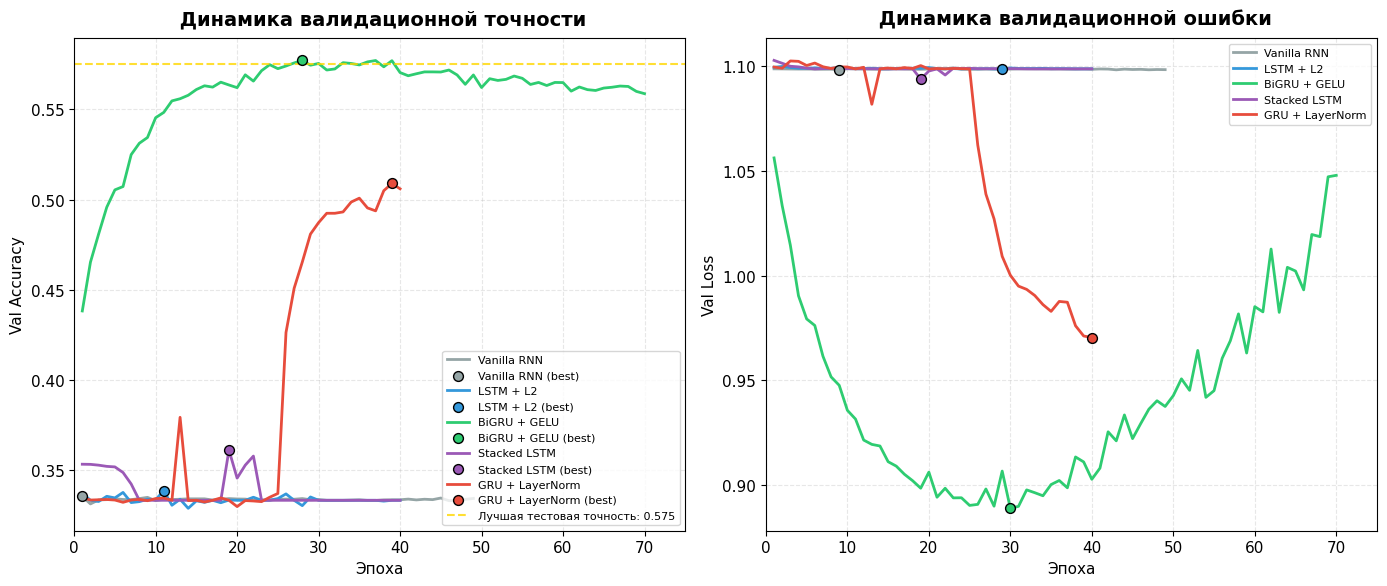


 ДИАГНОСТИКА ОБОБЩАЮЩЕЙ СПОСОБНОСТИ:
Модель               |   Test Acc | Best Val Acc |    Gap | Статус         
---------------------------------------------------------------------------
BiGRU + GELU         |     0.5753 |       0.5772 | -0.0019 |  Сбалансирована
Stacked LSTM         |     0.3453 |       0.3612 | -0.0159 |  Сбалансирована
Vanilla RNN          |     0.3345 |       0.3355 | -0.0010 |  Сбалансирована
GRU + LayerNorm      |     0.3323 |       0.5090 | -0.1767 | ️ Переобучение
LSTM + L2            |     0.3310 |       0.3387 | -0.0076 |  Сбалансирована
---------------------------------------------------------------------------

 Интерпретация:
    Gap < 0.02  → модель хорошо обобщает
    Gap < -0.02 → переобучение (валидация лучше теста)
    Gap > +0.02 → недообучение (тест лучше валидации, редкий случай)


In [168]:
print("БЛОК 35: Финальная оценка на тестовой выборке и визуализация")
# =============================================================================
# ИМПОРТЫ
# =============================================================================
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)  # Скрывает UndefinedMetricWarning и другие шумные уведомления
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# ИНИЦИАЛИЗАЦИЯ
# =============================================================================
results = []
best_model_name = None
best_test_acc = -1.0
best_val_acc_per_model = {}

print("\n" + "="*65)
print(" ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*65)

# =============================================================================
# 1. ОЦЕНКА КАЖДОЙ МОДЕЛИ
# =============================================================================
for name, model in models.items():
    # Предсказание на тестовой выборке
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    
    # Метрики
    acc_test = accuracy_score(y_test, y_pred)
    
    # Отчёт с zero_division=0 для подавления предупреждений
    report = classification_report(
        y_test, y_pred, 
        target_names=['positive', 'negative', 'neutral'], 
        output_dict=True,
        zero_division=0
    )
    
    # Лучшая валидационная точность из истории
    best_val = max(histories[name].history['val_accuracy'])
    best_val_acc_per_model[name] = best_val
    
    # Сохранение результатов
    results.append({
        'Модель': name,
        'Test Accuracy': acc_test,
        'Best Val Accuracy': best_val,
        'F1_macro': report['macro avg']['f1-score'],
        'Precision_macro': report['macro avg']['precision'],
        'Recall_macro': report['macro avg']['recall']
    })
    
    # Обновление лучшей модели
    if acc_test > best_test_acc:
        best_test_acc = acc_test
        best_model_name = name
    
    # Вывод отчёта по модели
    print(f"\n {name}")
    print(f"   Test Accuracy: {acc_test:.4f} | Best Val Accuracy: {best_val:.4f}")
    print(classification_report(y_test, y_pred, target_names=['positive', 'negative', 'neutral'], zero_division=0))
    print("-" * 65)

# =============================================================================
# 2. СВОДНАЯ ТАБЛИЦА
# =============================================================================
df_results = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(df_results.round(4).to_string(index=False))
print(f"\n Лучшая модель для инференса: {best_model_name} (Test Accuracy: {best_test_acc:.4f})")

# =============================================================================
# 3. ВИЗУАЛИЗАЦИЯ: ДИНАМИКА ОБУЧЕНИЯ
# =============================================================================
plt.figure(figsize=(14, 6))

# --- График 1: Валидационная точность ---
plt.subplot(1, 2, 1)
colors = {'Vanilla RNN': '#95a5a6', 'LSTM + L2': '#3498db', 'BiGRU + GELU': '#2ecc71', 
          'Stacked LSTM': '#9b59b6', 'GRU + LayerNorm': '#e74c3c'}

for name, hist in histories.items():
    epochs = range(1, len(hist.history['val_accuracy']) + 1)
    plt.plot(epochs, hist.history['val_accuracy'], 
             label=name, linewidth=2, color=colors.get(name, '#333'))
    # Маркер лучшей эпохи
    best_val = best_val_acc_per_model[name]
    best_epoch = np.argmax(hist.history['val_accuracy']) + 1
    plt.scatter(best_epoch, best_val, s=50, edgecolors='black', 
                facecolors=colors.get(name, '#333'), zorder=5, label=f'{name} (best)')

plt.axhline(y=best_test_acc, color='gold', linestyle='--', linewidth=1.5, 
            label=f'Лучшая тестовая точность: {best_test_acc:.3f}', alpha=0.8)
plt.title(' Динамика валидационной точности', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Эпоха', fontsize=11)
plt.ylabel('Val Accuracy', fontsize=11)
plt.legend(fontsize=8, loc='lower right', ncol=1)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, max(len(h.history['val_accuracy']) for h in histories.values()) + 5)

# --- График 2: Валидационная ошибка ---
plt.subplot(1, 2, 2)
for name, hist in histories.items():
    epochs = range(1, len(hist.history['val_loss']) + 1)
    plt.plot(epochs, hist.history['val_loss'], 
             label=name, linewidth=2, color=colors.get(name, '#333'))
    # Маркер минимальной ошибки
    min_loss = min(hist.history['val_loss'])
    min_epoch = np.argmin(hist.history['val_loss']) + 1
    plt.scatter(min_epoch, min_loss, s=50, edgecolors='black', 
                facecolors=colors.get(name, '#333'), zorder=5)

plt.title(' Динамика валидационной ошибки', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Эпоха', fontsize=11)
plt.ylabel('Val Loss', fontsize=11)
plt.legend(fontsize=8, loc='upper right', ncol=1)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, max(len(h.history['val_loss']) for h in histories.values()) + 5)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ДИАГНОСТИКА ОБОБЩАЮЩЕЙ СПОСОБНОСТИ
# =============================================================================
print("\n ДИАГНОСТИКА ОБОБЩАЮЩЕЙ СПОСОБНОСТИ:")
print(f"{'Модель':<20} | {'Test Acc':>10} | {'Best Val Acc':>12} | {'Gap':>6} | {'Статус':<15}")
print("-" * 75)

for _, row in df_results.iterrows():
    gap = row['Test Accuracy'] - row['Best Val Accuracy']
    if abs(gap) < 0.02:
        status = " Сбалансирована"
    elif gap < -0.02:
        status = "️ Переобучение"
    else:
        status = " Недообучение"
    print(f"{row['Модель']:<20} | {row['Test Accuracy']:>10.4f} | {row['Best Val Accuracy']:>12.4f} | {gap:>+6.4f} | {status}")

print("-" * 75)
print("\n Интерпретация:")
print("    Gap < 0.02  → модель хорошо обобщает")
print("    Gap < -0.02 → переобучение (валидация лучше теста)")
print("    Gap > +0.02 → недообучение (тест лучше валидации, редкий случай)")

In [169]:
print("БЛОК 36: Сохранение лучшей модели и артефактов")
import pickle
import os

# Автоматический выбор лучшей модели из Блока 35
best_model = models[best_model_name]

# Пути сохранения (файлы появятся в папке запуска ноутбука)
MODEL_PATH = "best_lstm_model.keras"
TOKENIZER_PATH = "tokenizer.pkl"
EMBED_MATRIX_PATH = "embed_matrix.npy"

# 1. Сохранение весов и архитектуры
best_model.save(MODEL_PATH)

# 2. Сохранение словаря токенизатора
with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)

# 3. Сохранение матрицы эмбеддингов (3001 x 8)
np.save(EMBED_MATRIX_PATH, embed_matrix)

print(f" Артефакты сохранены:")
print(f"    Модель       : {MODEL_PATH} ({os.path.getsize(MODEL_PATH)/1024:.1f} КБ)")
print(f"    Токенизатор  : {TOKENIZER_PATH}")
print(f"    Эмбеддинги   : {EMBED_MATRIX_PATH}")

БЛОК 36: Сохранение лучшей модели и артефактов
 Артефакты сохранены:
    Модель       : best_lstm_model.keras (398.9 КБ)
    Токенизатор  : tokenizer.pkl
    Эмбеддинги   : embed_matrix.npy


In [165]:
print("БЛОК 36: Экспорт словаря токенизатора в Excel")
import pandas as pd
import os

# 1. Извлекаем словарь (слово → индекс)
word_index = tokenizer.word_index

# 2. Сортируем по индексам для удобного просмотра
sorted_vocab = sorted(word_index.items(), key=lambda x: x[1])

# 3. Создаём DataFrame
df_vocab = pd.DataFrame(sorted_vocab, columns=['Слово', 'Токен (Индекс)'])

# 4. Добавляем специальные токены (0 и 1)
special_tokens = pd.DataFrame([
    ['<PAD>', 0],
    ['<OOV>', 1]
], columns=['Слово', 'Токен (Индекс)'])

# Объединяем, убираем дубли (если <OOV> уже попал в word_index) и сортируем
df_vocab = pd.concat([special_tokens, df_vocab], ignore_index=True)
df_vocab = df_vocab.drop_duplicates(subset='Токен (Индекс)')
df_vocab = df_vocab.sort_values('Токен (Индекс)').reset_index(drop=True)

# 5. Сохраняем в Excel
EXCEL_PATH = "tokenizer_vocabulary.xlsx"
df_vocab.to_excel(EXCEL_PATH, index=False, engine='openpyxl')

print(f" Словарь сохранён: {EXCEL_PATH}")
print(f" Всего записей: {len(df_vocab)}")
print("\n Первые 10 строк:")
print(df_vocab.head(10).to_string(index=False))

БЛОК 36: Экспорт словаря токенизатора в Excel
 Словарь сохранён: tokenizer_vocabulary.xlsx
 Всего записей: 55994

 Первые 10 строк:
 Слово  Токен (Индекс)
 <PAD>               0
 <OOV>               1
    не               2
    на               3
     и               4
     в               5
 очень               6
    но               7
размер               8
   что               9
